# BÁO CÁO BÀI TẬP LỚN: DỰ ĐOÁN GIÁ NHÀ CALIFORNIA BẰNG MÔ HÌNH HỒI QUY

---

## Giới thiệu bài toán

Bài toán đặt ra là: **dựa vào các thông tin về một khu vực dân cư ở California (thu nhập, tuổi nhà, số phòng, dân số, vị trí địa lý…), dự đoán giá nhà trung vị của khu vực đó.**

Đây là bài toán **hồi quy (regression)** — biến mục tiêu `MedHouseVal` là giá trị liên tục (đơn vị: trăm nghìn USD), không phải nhãn phân loại rời rạc. Mô hình cần học được mối quan hệ giữa các đặc trưng đầu vào và giá nhà để đưa ra dự đoán cho dữ liệu mới.

### Bộ dữ liệu

Sử dụng bộ **California Housing** được tích hợp sẵn trong thư viện scikit-learn. Bộ dữ liệu này thu thập từ cuộc điều tra dân số Mỹ năm 1990, gồm thông tin về 20.640 khu vực (block group) tại bang California. Mỗi mẫu đại diện cho một nhóm hộ gia đình trong cùng một khu vực địa lý.

| Đặc trưng | Ý nghĩa |
|---|---|
| `MedInc` | Thu nhập trung vị của các hộ gia đình trong khu vực (đơn vị: chục nghìn USD) |
| `HouseAge` | Tuổi trung vị của các ngôi nhà trong khu vực (năm) |
| `AveRooms` | Số phòng trung bình trên mỗi hộ |
| `AveBedrms` | Số phòng ngủ trung bình trên mỗi hộ |
| `Population` | Dân số khu vực |
| `AveOccup` | Số người trung bình trên mỗi hộ |
| `Latitude` | Vĩ độ |
| `Longitude` | Kinh độ |
| **`MedHouseVal`** | **Giá nhà trung vị (biến mục tiêu, đơn vị: trăm nghìn USD)** |

### Hướng tiếp cận

Notebook thực hiện toàn bộ quy trình machine learning từ đầu đến cuối:

1. **Khám phá dữ liệu (EDA):** Kiểm tra phân phối, giá trị thiếu, outlier, tương quan giữa các biến.
2. **Tiền xử lý:** Biến đổi log cho nhãn, loại bỏ ngoại lệ, chuẩn hóa đặc trưng.
3. **Huấn luyện mô hình:** So sánh hai mô hình — **Linear Regression** (mô hình tuyến tính cơ sở) và **Gradient Boosting Regressor** (mô hình ensemble phi tuyến).
4. **Đánh giá:** Dùng các chỉ số MAE, RMSE, R² và biểu đồ so sánh giá trị thực – giá trị dự đoán.

Mục tiêu là tìm mô hình dự đoán giá nhà chính xác nhất, đồng thời hiểu được yếu tố nào ảnh hưởng nhiều nhất đến giá nhà tại California.

---

## Mục lục

1. [Khai báo thư viện](#muc-1)
2. [Tải và xem tổng quan dữ liệu](#muc-2)
3. [Tách biến mục tiêu](#muc-3)
4. [Kiểm tra giá trị thiếu](#muc-4)
5. [Biến đổi log cho biến mục tiêu](#muc-5)
6. [Khám phá phân phối giá nhà và quan hệ với thu nhập](#muc-6)
7. [Xử lý ngoại lệ và Feature Engineering](#muc-7)
8. [Chia tập dữ liệu và chuẩn hóa đặc trưng](#muc-8)
9. [Phân tích tương quan với giá nhà](#muc-9)
10. [Cross-validation và tuning siêu tham số](#muc-12) *(gộp trong phần Gradient Boosting)*
11. [Huấn luyện và đánh giá mô hình Linear Regression](#muc-11)
12. [Huấn luyện, cross-validation và tuning mô hình Gradient Boosting Regressor](#muc-12)
13. [Trực quan hóa và so sánh kết quả dự đoán](#muc-13)



<a id="muc-1"></a>
## 1. Chuẩn bị môi trường và thư viện

Import các thư viện xử lý dữ liệu, trực quan hóa và xây dựng mô hình hồi quy; thiết lập giao diện biểu đồ bằng `seaborn`.

In [1]:
# Nạp các thư viện tính toán và quản lý dữ liệu dạng bảng
import numpy as np
import pandas as pd

# Nạp các thư viện trực quan hóa để khảo sát phân phối và kết quả dự đoán
import matplotlib.pyplot as plt
import seaborn as sns

# Hàm lấy bộ dữ liệu California Housing tích hợp trong scikit-learn
from sklearn.datasets import fetch_california_housing

# Các công cụ chia dữ liệu và chuẩn hóa đặc trưng trước khi huấn luyện
from sklearn.model_selection import train_test_split, GridSearchCV, KFold, cross_validate
from sklearn.preprocessing import StandardScaler

# Hai mô hình hồi quy dùng để xây dựng đường cơ sở và mô hình cải thiện
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor

# Các thước đo đánh giá sai số và khả năng giải thích của mô hình
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Thiết lập giao diện chung giúp các biểu đồ dễ đọc và thống nhất trong báo cáo
sns.set(style="whitegrid", font_scale=1.0)

<a id="muc-2"></a>
## 2. Tải và xem tổng quan dữ liệu

Tải bộ dữ liệu California Housing từ scikit-learn, kiểm tra kích thước, kiểu dữ liệu, thống kê mô tả và dòng trùng lặp.

In [2]:
# Tải bộ dữ liệu dưới dạng DataFrame để giữ tên cột và thuận tiện khi phân tích
housing = fetch_california_housing(as_frame=True)

# housing.frame chứa đồng thời 8 thuộc tính đầu vào và nhãn MedHouseVal
df = housing.frame.copy()

print("5 dòng đầu:")
display(df.head())

print("Kích thước dữ liệu gốc:", df.shape)
print("Tên cột:", df.columns.tolist())

print("Kiểu dữ liệu từng cột:")
display(df.dtypes.to_frame("dtype"))

print("Thống kê mô tả:")
display(df.describe().T)

print("Số dòng trùng lặp hoàn toàn:", df.duplicated().sum())


5 dòng đầu:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


Kích thước dữ liệu gốc: (20640, 9)
Tên cột: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal']
Kiểu dữ liệu từng cột:


,dtype
MedInc,float64
HouseAge,float64
AveRooms,float64
AveBedrms,float64
Population,float64
AveOccup,float64
Latitude,float64
Longitude,float64
MedHouseVal,float64


Thống kê mô tả:


,count,mean,std,min,25%,50%,75%,max
MedInc,20640.0,3.870671,1.899822,0.499900,2.563400,3.534800,4.743250,15.000100
HouseAge,20640.0,28.639486,12.585558,1.000000,18.000000,29.000000,37.000000,52.000000
AveRooms,20640.0,5.429000,2.474173,0.846154,4.440716,5.229129,6.052381,141.909091
AveBedrms,20640.0,1.096675,0.473911,0.333333,1.006079,1.048780,1.099526,34.066667
Population,20640.0,1425.476744,1132.462122,3.000000,787.000000,1166.000000,1725.000000,35682.000000
AveOccup,20640.0,3.070655,10.386050,0.692308,2.429741,2.818116,3.282261,1243.333333
Latitude,20640.0,35.631861,2.135952,32.540000,33.930000,34.260000,37.710000,41.950000
Longitude,20640.0,-119.569704,2.003532,-124.350000,-121.800000,-118.490000,-118.010000,-114.310000
MedHouseVal,20640.0,2.068558,1.153956,0.149990,1.196000,1.797000,2.647250,5.000010


Số dòng trùng lặp hoàn toàn: 0


### Output thu được và nhận xét dữ liệu

Bộ dữ liệu California Housing gồm **20.640 mẫu** (mỗi mẫu đại diện cho một nhóm hộ gia đình trong một khu vực địa lý) và **9 cột** (8 đặc trưng + 1 biến mục tiêu). Các đặc trưng bao gồm thu nhập trung vị (`MedInc`), tuổi nhà (`HouseAge`), số phòng trung bình (`AveRooms`), dân số (`Population`), tọa độ vĩ độ–kinh độ (`Latitude`, `Longitude`), v.v. Biến mục tiêu `MedHouseVal` là giá nhà trung vị.

Nhìn vào kết quả ta rút ra mấy điểm chính:

| Nội dung kiểm tra | Kết quả | Ý nghĩa thực tế |
|---|---|---|
| Kiểu dữ liệu | Tất cả 9 cột đều là `float64` | Toàn bộ biến đều là số liên tục, không có biến phân loại nên không cần bước mã hóa (One-Hot, Label Encoding...) |
| Thống kê mô tả | Thang đo chênh lệch lớn: ví dụ `MedInc` trung bình ~3.87, `Population` trung bình ~1425 | Do thang đo khác nhau nên nếu dùng mô hình tuyến tính sẽ cần chuẩn hóa (StandardScaler) để các hệ số không bị lệch |
| Giá trị max bất thường | `AveRooms` max = 141.9, `AveOccup` max = 1243.3, `Population` max = 35682 | Có khả năng tồn tại outlier, cần kiểm tra kỹ hơn ở bước EDA |
| `MedHouseVal` | Min = 0.15, Max = 5.0001 (đơn vị ×100.000 USD) | Giá nhà dao động từ khoảng 15.000 đến 500.000 USD; giá trị max đúng bằng 5.0001 cho thấy bộ dữ liệu đã bị cắt trên (cap) ở mức 500.001 USD |
| Dòng trùng lặp | 0 dòng trùng | Không có bản ghi nào lặp hoàn toàn, dữ liệu sạch về mặt trùng lặp |

Tóm lại, đây là bộ dữ liệu khá chuẩn chỉnh, không có biến phân loại, không có trùng lặp. Tuy nhiên vì thang đo khác nhau giữa các cột nên cần phải chuẩn hóa đặc trưng trước khi đưa vào mô hình hồi quy tuyến tính. Ngoài ra cũng cần kiểm tra giá trị thiếu và outlier ở các bước tiếp theo.


<a id="muc-3"></a>
## 3. Tách biến mục tiêu

Tách `MedHouseVal` thành biến mục tiêu `y`, giữ các thuộc tính dự báo trong `dfprocessed`.

In [3]:
# Tạo bản sao làm việc nhằm giữ nguyên dữ liệu gốc trong biến df
dfprocessed = df.copy()

# Tách biến mục tiêu: MedHouseVal là giá nhà trung vị, đơn vị 100.000 USD
y = dfprocessed["MedHouseVal"]

# Loại biến mục tiêu khỏi tập đặc trưng để tránh rò rỉ nhãn khi huấn luyện
dfprocessed = dfprocessed.drop(["MedHouseVal"], axis=1)

# Kiểm tra số dòng của X và y phải bằng nhau sau thao tác tách nhãn
print("Shape dfprocessed:", dfprocessed.shape)
print("Shape y:", y.shape)
print("Chưa áp dụng log-transform ở bước này; log1p sẽ được thực hiện sau kiểm tra giá trị thiếu.")


Shape dfprocessed: (20640, 8)
Shape y: (20640,)
Chưa áp dụng log-transform ở bước này; log1p sẽ được thực hiện sau kiểm tra giá trị thiếu.


### Output thu được và nhận xét tách nhãn

Sau khi tách, ta thu được:

| Thành phần | Kích thước | Giải thích |
|---|---:|---|
| Tập thuộc tính `dfprocessed` | `(20640, 8)` | 20.640 mẫu × 8 đặc trưng đầu vào, đã bỏ cột `MedHouseVal` |
| Vector nhãn `y` | `(20640,)` | 20.640 giá trị giá nhà trung vị tương ứng |

Bước tách nhãn này rất quan trọng vì nếu để `MedHouseVal` nằm chung với các đặc trưng thì khi huấn luyện, mô hình sẽ bị **rò rỉ nhãn** (data leakage): tức là mô hình "nhìn thấy" đáp án trong lúc học, dẫn đến kết quả đánh giá không phản ánh đúng khả năng thực tế.

<a id="muc-4"></a>
## 4. Kiểm tra giá trị thiếu

Thống kê số lượng giá trị khuyết trên từng đặc trưng và trên biến mục tiêu trước khi biến đổi log. Đây là thứ tự đúng: kiểm tra dữ liệu thiếu trước, sau đó mới áp dụng biến đổi toán học lên nhãn.


In [4]:
# Đếm số ô bị khuyết trong từng đặc trưng đầu vào
missing_features = dfprocessed.isnull().sum()

# Kiểm tra riêng biến mục tiêu trước khi áp dụng log-transform
missing_target = y.isnull().sum()

missing_summary = pd.DataFrame({
    "missing_count": missing_features,
    "missing_percent": missing_features / len(dfprocessed) * 100
})

print("Giá trị thiếu ở đặc trưng:")
display(missing_summary[missing_summary["missing_count"] > 0])
print("Số giá trị thiếu ở biến mục tiêu MedHouseVal:", missing_target)
print("Số dòng trùng lặp trong tập đặc trưng:", dfprocessed.duplicated().sum())


Giá trị thiếu ở đặc trưng:


,missing_count,missing_percent


Số giá trị thiếu ở biến mục tiêu MedHouseVal: 0
Số dòng trùng lặp trong tập đặc trưng: 0


### Output thu được và nhận xét giá trị thiếu

Kết quả cho thấy:
- **Đặc trưng**: Bảng `missing_summary` trả về DataFrame rỗng — nghĩa là không có cột nào chứa giá trị thiếu.
- **Biến mục tiêu**: Số giá trị thiếu ở `MedHouseVal` = **0**.
- **Dòng trùng lặp**: 0 dòng trùng trong tập đặc trưng.

Đây là điều khá thuận lợi vì bộ dữ liệu California Housing được lấy từ scikit-learn đã được tiền xử lý sẵn, nên không tồn tại giá trị `NaN`. Trong thực tế, nếu có missing values thì ta phải quyết định cách xử lý: có thể điền bằng trung vị (median), trung bình (mean), hoặc loại bỏ dòng tùy theo tỷ lệ thiếu.

Vì không có giá trị thiếu, ta có thể yên tâm chuyển sang bước biến đổi log cho biến mục tiêu mà không sợ gặp lỗi tính toán.


<a id="muc-5"></a>
## 5. Biến đổi log cho biến mục tiêu

Sau khi đã xác nhận không có giá trị thiếu, áp dụng `log1p` cho `MedHouseVal` để giảm độ lệch phải của phân phối giá nhà. Việc biến đổi nhãn được thực hiện trước khi chia train/validation để cả hai tập cùng dùng một thang đo nhất quán; khi đánh giá, dự đoán được chuyển ngược bằng `expm1` về thang giá gốc.


In [5]:
# Sử dụng biến điều khiển để có thể bật/tắt biến đổi log của giá nhà
use_log_transform = True

# log1p giúp giảm độ lệch phải của nhãn và vẫn xử lý an toàn giá trị bằng 0
if use_log_transform:
    y = np.log1p(y)
    print("Đã áp dụng log1p cho MedHouseVal sau bước kiểm tra giá trị thiếu.")
else:
    print("Không dùng log-transform cho y.")

print("5 giá trị đầu của y sau bước xử lý nhãn:")
display(y.head())


Đã áp dụng log1p cho MedHouseVal sau bước kiểm tra giá trị thiếu.
5 giá trị đầu của y sau bước xử lý nhãn:


0    1.709464
1    1.522790
2    1.508733
3    1.484555
4    1.486592
Name: MedHouseVal, dtype: float64

### Output thu được và nhận xét biến đổi log

Sau khi áp dụng `log1p`, 5 giá trị đầu của `y` đã thay đổi từ thang gốc (ví dụ 4.526) sang thang log (ví dụ 1.709). Mục đích của bước này:

- **Giảm độ lệch phải (right skew):** Phân phối giá nhà gốc thường bị lệch phải — tức là đa số nhà có giá trung bình nhưng một số ít có giá rất cao. Khi dùng `log1p`, các giá trị cao bị "nén" lại, giúp phân phối trở nên đối xứng hơn.
- **Ổn định phương sai:** Mô hình hồi quy tuyến tính hoạt động tốt hơn khi phương sai của nhãn không thay đổi quá lớn theo giá trị (tính homoscedasticity). Log-transform giúp cải thiện điều này.
- **Tại sao dùng `log1p` thay vì `log`?** Vì `log1p(x) = log(1 + x)`, nó xử lý được cả trường hợp `x = 0` mà không bị lỗi (log(0) = -∞). Tuy trong bộ dữ liệu này giá nhà > 0, nhưng dùng `log1p` là an toàn.

Khi đánh giá mô hình sau này, ta sẽ cần dùng `expm1` (hàm ngược của `log1p`) để chuyển dự đoán ngược về thang giá gốc, từ đó tính sai số MAE và RMSE có ý nghĩa thực tế (đơn vị USD).


<a id="muc-6"></a>
## 6. Khai phá phân phối giá nhà và quan hệ với thu nhập

Trực quan hóa phân phối `MedHouseVal` trên thang giá trị gốc và sau log, khảo sát quan hệ với các biến quan trọng, đồng thời xem yếu tố vị trí địa lý.

Thống kê mô tả các biến chính:


,count,mean,std,min,25%,50%,75%,max
MedInc,20640.0,3.870671,1.899822,0.499900,2.563400,3.534800,4.743250,15.000100
HouseAge,20640.0,28.639486,12.585558,1.000000,18.000000,29.000000,37.000000,52.000000
AveRooms,20640.0,5.429000,2.474173,0.846154,4.440716,5.229129,6.052381,141.909091
AveOccup,20640.0,3.070655,10.386050,0.692308,2.429741,2.818116,3.282261,1243.333333
Population,20640.0,1425.476744,1132.462122,3.000000,787.000000,1166.000000,1725.000000,35682.000000
MedHouseVal,20640.0,2.068558,1.153956,0.149990,1.196000,1.797000,2.647250,5.000010


Độ lệch skewness của nhãn:


,skewness
MedHouseVal,0.977763
MedHouseVal_log1p,0.275939


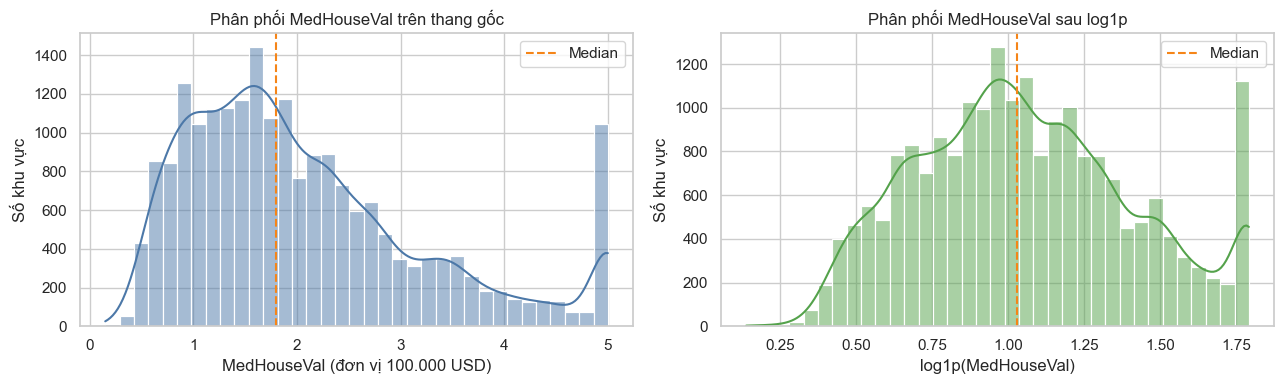

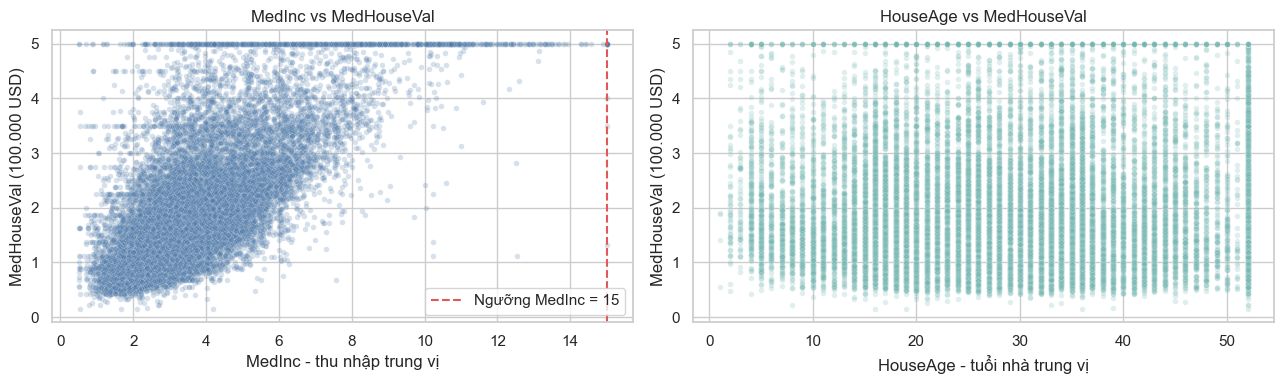

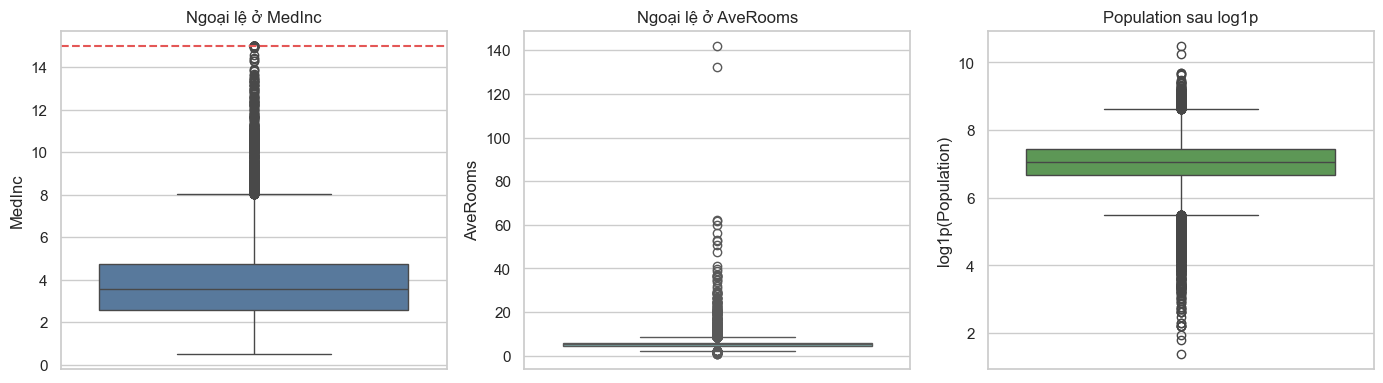

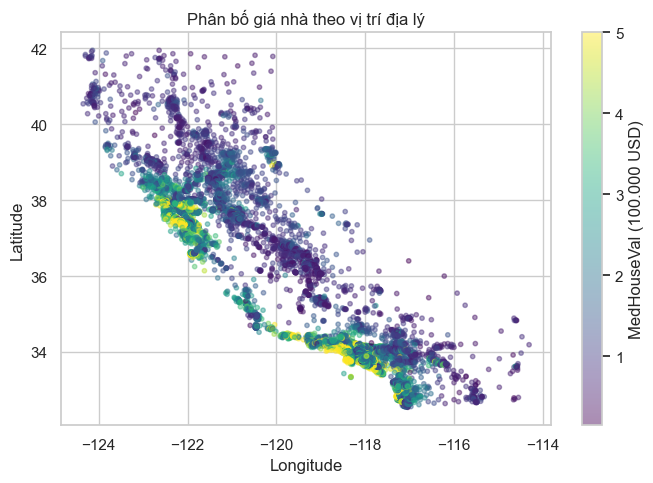

In [6]:
# Đưa nhãn đã biến đổi log trở lại thang giá gốc khi vẽ biểu đồ để dễ diễn giải
if use_log_transform:
    target_for_plot = np.expm1(y)
else:
    target_for_plot = y

eda_df = dfprocessed.copy()
eda_df["MedHouseVal"] = target_for_plot
eda_df["MedHouseVal_log1p"] = np.log1p(target_for_plot)

print("Thống kê mô tả các biến chính:")
display(eda_df[["MedInc", "HouseAge", "AveRooms", "AveOccup", "Population", "MedHouseVal"]].describe().T)

print("Độ lệch skewness của nhãn:")
display(eda_df[["MedHouseVal", "MedHouseVal_log1p"]].skew().to_frame("skewness"))

# 1. So sánh phân phối nhãn trước và sau log-transform.
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(eda_df["MedHouseVal"], bins=35, kde=True, color="#4C78A8", ax=axes[0])
axes[0].axvline(eda_df["MedHouseVal"].median(), color="#F58518", linestyle="--", label="Median")
axes[0].set_title("Phân phối MedHouseVal trên thang gốc")
axes[0].set_xlabel("MedHouseVal (đơn vị 100.000 USD)")
axes[0].set_ylabel("Số khu vực")
axes[0].legend()

sns.histplot(eda_df["MedHouseVal_log1p"], bins=35, kde=True, color="#54A24B", ax=axes[1])
axes[1].axvline(eda_df["MedHouseVal_log1p"].median(), color="#F58518", linestyle="--", label="Median")
axes[1].set_title("Phân phối MedHouseVal sau log1p")
axes[1].set_xlabel("log1p(MedHouseVal)")
axes[1].set_ylabel("Số khu vực")
axes[1].legend()
plt.tight_layout()
plt.show()

# 2. Quan hệ giữa thu nhập, tuổi nhà và giá nhà.
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.scatterplot(data=eda_df, x="MedInc", y="MedHouseVal", alpha=0.22, s=16, color="#4C78A8", ax=axes[0])
axes[0].axvline(15, color="#E45756", linestyle="--", label="Ngưỡng MedInc = 15")
axes[0].set_title("MedInc vs MedHouseVal")
axes[0].set_xlabel("MedInc - thu nhập trung vị")
axes[0].set_ylabel("MedHouseVal (100.000 USD)")
axes[0].legend()

sns.scatterplot(data=eda_df, x="HouseAge", y="MedHouseVal", alpha=0.22, s=16, color="#72B7B2", ax=axes[1])
axes[1].set_title("HouseAge vs MedHouseVal")
axes[1].set_xlabel("HouseAge - tuổi nhà trung vị")
axes[1].set_ylabel("MedHouseVal (100.000 USD)")
plt.tight_layout()
plt.show()

# 3. Boxplot giúp nhận diện ngoại lệ. Dùng thang log cho Population vì biến này có đuôi rất dài.
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
sns.boxplot(y=eda_df["MedInc"], color="#4C78A8", ax=axes[0])
axes[0].axhline(15, color="#E45756", linestyle="--")
axes[0].set_title("Ngoại lệ ở MedInc")
axes[0].set_ylabel("MedInc")

sns.boxplot(y=eda_df["AveRooms"], color="#72B7B2", ax=axes[1])
axes[1].set_title("Ngoại lệ ở AveRooms")
axes[1].set_ylabel("AveRooms")

sns.boxplot(y=np.log1p(eda_df["Population"]), color="#54A24B", ax=axes[2])
axes[2].set_title("Population sau log1p")
axes[2].set_ylabel("log1p(Population)")
plt.tight_layout()
plt.show()

# 4. Vị trí địa lý là tín hiệu quan trọng của bài toán giá nhà.
plt.figure(figsize=(7, 5))
scatter = plt.scatter(
    eda_df["Longitude"],
    eda_df["Latitude"],
    c=eda_df["MedHouseVal"],
    cmap="viridis",
    alpha=0.45,
    s=10
)
plt.colorbar(scatter, label="MedHouseVal (100.000 USD)")
plt.title("Phân bố giá nhà theo vị trí địa lý")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.tight_layout()
plt.show()


### Phân tích output trực quan hóa dữ liệu

#### Đánh giá các biểu đồ

Phần EDA gồm 4 nhóm biểu đồ chính, mỗi nhóm phục vụ một mục đích khác nhau:

| STT | Biểu đồ | Quan sát được gì |
|:---:|---|---|
| 1 | **Histogram + KDE** của `MedHouseVal` (gốc vs log) | Phân phối gốc lệch phải rõ rệt, có đỉnh nhọn tại giá trị cap 5.0. Sau log, phân phối đối xứng hơn đáng kể, skewness giảm từ ~0.98 xuống ~0.28 |
| 2 | **Scatter plot** `MedInc` vs `MedHouseVal` | Thu nhập trung vị có quan hệ tuyến tính khá rõ với giá nhà — khu vực thu nhập cao thì giá nhà cũng cao. Đây là đặc trưng quan trọng nhất |
| 3 | **Boxplot** các biến số chính | Giúp nhìn thấy outlier: `MedInc` có điểm chạm ngưỡng 15, `AveRooms` có giá trị rất cao; thống kê mô tả cũng cho thấy `AveOccup` có giá trị cực đại bất thường 1243.33 người/hộ |
| 4 | **Scatter plot** `Latitude` vs `Longitude` (màu theo giá nhà) | Cho thấy yếu tố vị trí ảnh hưởng rõ đến giá: vùng ven biển (Bay Area, Los Angeles) có giá cao hơn vùng nội địa |

#### Nhận xét tổng hợp

- Biến `MedInc` rõ ràng là đặc trưng dự báo quan trọng nhất, có tương quan dương mạnh với giá nhà.
- Vị trí địa lý (`Latitude`, `Longitude`) cũng đóng vai trò đáng kể — điều này hợp lý vì nhà ở California, giá phụ thuộc nhiều vào khu vực.
- Có một số outlier đáng chú ý ở `MedInc`, `AveOccup` và `AveRooms`. Các điểm này chỉ chiếm tỷ lệ nhỏ nhưng có thể kéo lệch mô hình, đặc biệt với Linear Regression.
- Việc dùng log-transform cho nhãn là quyết định đúng vì phân phối gốc lệch phải quá mạnh, sẽ khiến mô hình tuyến tính học không tốt.

Dựa vào kết quả EDA và thống kê mô tả, bước tiếp theo sẽ lọc các ngoại lệ rõ ràng ở `MedInc`, `AveOccup`, `AveRooms`, sau đó tạo thêm đặc trưng phái sinh để mô hình khai thác tốt hơn quan hệ giữa thu nhập, số phòng, dân số và mức độ đông đúc.


<a id="muc-7"></a>
## 7. Xử lý ngoại lệ và Feature Engineering

Lọc các quan sát bất thường ở `MedInc`, `AveOccup`, `AveRooms` nhằm giảm ảnh hưởng của những điểm quá cực đoan lên quá trình huấn luyện. Sau đó tạo thêm các đặc trưng phái sinh từ biến gốc để biểu diễn rõ hơn mức độ rộng rãi, tỷ lệ phòng ngủ, quy mô hộ và sức mua tương đối.

In [7]:
# Loại outlier ở MedInc >= 15 (xác định từ EDA)
indices_to_keep = dfprocessed[dfprocessed["MedInc"] < 15].index
dfprocessed = dfprocessed.loc[indices_to_keep]
y = y.loc[indices_to_keep]

# Loại thêm outlier ở AveOccup (trung bình người/hộ) quá cao (> 10 là bất thường)
indices_to_keep = dfprocessed[dfprocessed["AveOccup"] < 10].index
dfprocessed = dfprocessed.loc[indices_to_keep]
y = y.loc[indices_to_keep]

# Loại AveRooms bất thường (> 50 phòng/hộ là không hợp lý)
indices_to_keep = dfprocessed[dfprocessed["AveRooms"] < 50].index
dfprocessed = dfprocessed.loc[indices_to_keep]
y = y.loc[indices_to_keep]

print("Shape sau khi loại outlier (MedInc, AveOccup, AveRooms):", dfprocessed.shape)
print("Shape y:", y.shape)

# ── Feature Engineering: tạo đặc trưng phái sinh ──
# Tỷ lệ phòng ngủ / tổng phòng → phản ánh loại nhà (studio vs gia đình)
dfprocessed["BedroomRatio"] = dfprocessed["AveBedrms"] / dfprocessed["AveRooms"]

# Số phòng trên mỗi người → phản ánh mức độ rộng rãi
dfprocessed["RoomsPerPerson"] = dfprocessed["AveRooms"] / dfprocessed["AveOccup"]

# Mật độ dân số trên mỗi hộ → phản ánh đông đúc
dfprocessed["PopPerHousehold"] = dfprocessed["Population"] / dfprocessed["AveOccup"]

# Thu nhập trên mỗi phòng → sức mua trên diện tích
dfprocessed["IncomePerRoom"] = dfprocessed["MedInc"] / dfprocessed["AveRooms"]

print("\nCác đặc trưng mới đã tạo:", ["BedroomRatio", "RoomsPerPerson", "PopPerHousehold", "IncomePerRoom"])
print("Shape sau Feature Engineering:", dfprocessed.shape)
display(dfprocessed.head(3))


Shape sau khi loại outlier (MedInc, AveOccup, AveRooms): (20544, 8)
Shape y: (20544,)

Các đặc trưng mới đã tạo: ['BedroomRatio', 'RoomsPerPerson', 'PopPerHousehold', 'IncomePerRoom']
Shape sau Feature Engineering: (20544, 12)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,BedroomRatio,RoomsPerPerson,PopPerHousehold,IncomePerRoom
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,0.146591,2.732919,126.0,1.192017
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,0.155797,2.956685,1138.0,1.330750
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,0.129516,2.957661,177.0,0.875637


### Output thu được và nhận xét xử lý ngoại lệ + Feature Engineering

**Xử lý ngoại lệ:**

Dựa vào boxplot và thống kê mô tả ở phần EDA, loại bỏ các mẫu có giá trị bất thường ở 3 biến:

| Biến | Ngưỡng loại | Lý do |
|---|---|---|
| `MedInc` | >= 15 | Thu nhập trung vị >= 150.000 USD/năm — cực kỳ giàu, không đại diện cho xu hướng chung |
| `AveOccup` | >= 10 | Trung bình > 10 người/hộ — có thể là ký túc xá, khu tập thể hoặc lỗi dữ liệu |
| `AveRooms` | >= 50 | Trung bình > 50 phòng/hộ — không hợp lý cho khu dân cư bình thường |

Tổng cộng loại khoảng 96 mẫu (~0.5% dữ liệu), còn lại 20.544 mẫu — đủ lớn để huấn luyện mô hình.

**Feature Engineering:**

Tạo 4 đặc trưng phái sinh từ các cột có sẵn:

| Đặc trưng mới | Công thức | Ý nghĩa |
|---|---|---|
| `BedroomRatio` | AveBedrms / AveRooms | Tỷ lệ phòng ngủ trên tổng phòng — phản ánh loại nhà (studio vs gia đình) |
| `RoomsPerPerson` | AveRooms / AveOccup | Số phòng trên mỗi người — đo mức độ rộng rãi |
| `PopPerHousehold` | Population / AveOccup | Mật độ dân cư trên mỗi hộ |
| `IncomePerRoom` | MedInc / AveRooms | Thu nhập trên mỗi phòng — phản ánh sức mua trên diện tích |

Các đặc trưng này được chọn vì có ý nghĩa thực tế, không dùng thông tin của nhãn `MedHouseVal`, nên không gây rò rỉ dữ liệu. Chúng giúp mô hình nắm bắt các mối quan hệ mà từng biến riêng lẻ không thể hiện đầy đủ. Ví dụ, `IncomePerRoom` kết hợp thu nhập và số phòng để phản ánh sức mua tương đối trên quy mô nhà; `RoomsPerPerson` cho biết nhà rộng hay chật so với số người trung bình trong hộ.

Có thể tạo các đặc trưng khác, nhưng cần kiểm tra lại bằng tương quan, feature importance và chỉ số mô hình. Nếu đặc trưng mới không có ý nghĩa hoặc làm MAE/RMSE/R² xấu đi thì nên loại bỏ.

Sau bước này, tập dữ liệu có **12 đặc trưng** (8 gốc + 4 mới).


<a id="muc-8"></a>
## 8. Chia tập dữ liệu và chuẩn hóa đặc trưng

Chia dữ liệu theo tỷ lệ 80% huấn luyện và 20% validation với `random_state=42`.


In [8]:
# Chia dữ liệu: 80% dùng học mô hình, 20% dùng đánh giá độc lập
# random_state cố định giúp kết quả có thể tái lập khi chạy lại notebook
X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    dfprocessed,
    y,
    test_size=0.2,
    random_state=42
)

print("Kích thước X_train_raw:", X_train_raw.shape)
print("Kích thước X_val_raw:", X_val_raw.shape)
print("Kích thước y_train:", y_train.shape)
print("Kích thước y_val:", y_val.shape)

# Lưu bản train chưa chuẩn hóa để phục vụ EDA tương quan trên đúng tập train.
X_train_for_eda = X_train_raw.copy()

# Khởi tạo bộ chuẩn hóa theo công thức z-score: (x - trung bình) / độ lệch chuẩn
scaler = StandardScaler()

# Chỉ fit trên tập train để thông tin validation không rò rỉ vào quá trình học
X_train_scaled = scaler.fit_transform(X_train_raw)
X_val_scaled = scaler.transform(X_val_raw)

# Chuyển mảng sau chuẩn hóa về DataFrame để bảo toàn tên cột và index ban đầu
X_train = pd.DataFrame(X_train_scaled, columns=X_train_raw.columns, index=X_train_raw.index)
X_val = pd.DataFrame(X_val_scaled, columns=X_val_raw.columns, index=X_val_raw.index)

scaler_summary = pd.DataFrame({
    "mean_from_train": scaler.mean_,
    "scale_from_train": scaler.scale_
}, index=X_train_raw.columns)

print("Tham số scaler học từ train:")
display(scaler_summary)

print("5 dòng đầu X_train sau chuẩn hóa:")
display(X_train.head())


Kích thước X_train_raw: (16435, 12)
Kích thước X_val_raw: (4109, 12)
Kích thước y_train: (16435,)
Kích thước y_val: (4109,)
Tham số scaler học từ train:


,mean_from_train,scale_from_train
MedInc,3.852283,1.824084
HouseAge,28.547490,12.565215
AveRooms,5.394279,1.876982
AveBedrms,1.090295,0.322384
Population,1425.412108,1130.371625
AveOccup,2.919933,0.767266
Latitude,35.644936,2.141213
Longitude,-119.583527,2.007741
BedroomRatio,0.213126,0.057898
RoomsPerPerson,1.964651,0.914750


5 dòng đầu X_train sau chuẩn hóa:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,BedroomRatio,RoomsPerPerson,PopPerHousehold,IncomePerRoom
10804,1.753931,0.672691,-0.009946,-0.143904,-0.547087,-1.240301,-0.945696,0.823576,-0.327019,0.837881,-0.239040,2.393825
12369,1.256202,-0.919005,2.055361,1.377822,-0.295843,-0.741125,-0.870972,1.570684,-0.816516,2.153890,-0.096898,-0.200300
6231,0.824314,0.593106,0.145120,-0.338336,-0.656786,0.373586,-0.735534,0.823576,-0.690343,-0.215849,-0.757594,0.925579
6882,-0.681374,0.115598,-0.809557,-0.031205,0.741869,1.968804,-0.740205,0.743884,1.134089,-1.191684,0.026818,-0.162626
16948,1.894550,-0.123157,1.010193,-0.124313,-0.063176,0.047440,0.880372,-1.372923,-1.192974,0.548101,-0.112692,1.154936


### Output thu được và nhận xét chia tập, chuẩn hóa

**Kết quả chia dữ liệu**

| Tập dữ liệu | Kích thước | Vai trò |
|---|---:|---|
| `X_train` | `(16435, 12)` | Dùng để huấn luyện mô hình (80%) |
| `X_val` | `(4109, 12)` | Dùng để đánh giá mô hình (20%) |
| `y_train` | `(16435,)` | Nhãn giá nhà tương ứng tập train |
| `y_val` | `(4109,)` | Nhãn giá nhà tương ứng tập validation |

Số cột tăng từ 8 lên 12 do đã thêm 4 đặc trưng phái sinh ở bước Feature Engineering. Tập validation ở đây đóng vai trò hold-out evaluation set: không dùng để huấn luyện, chỉ dùng để đánh giá sau khi mô hình đã học từ train.

**Về chuẩn hóa (StandardScaler):**

StandardScaler chuyển đổi mỗi đặc trưng sao cho có trung bình xấp xỉ 0 và độ lệch chuẩn xấp xỉ 1 theo công thức: `z = (x - mean) / std`.

Các giá trị âm xuất hiện sau chuẩn hóa là bình thường. Số âm không có nghĩa là giá trị gốc bị âm; nó chỉ cho biết quan sát đó thấp hơn trung bình của đặc trưng trong tập train. Ví dụ `MedInc` sau chuẩn hóa âm nghĩa là thu nhập trung vị của khu vực đó thấp hơn mức trung bình train, còn giá trị dương nghĩa là cao hơn trung bình.

Điểm quan trọng: `scaler.fit()` chỉ được gọi trên `X_train` (để học `mean` và `std` từ tập train), sau đó `scaler.transform()` được áp dụng lên cả train và validation. Nếu fit trên toàn bộ dữ liệu (bao gồm cả validation) thì sẽ bị **data leakage** — mô hình gián tiếp "biết" thông tin từ tập validation trong lúc huấn luyện.

Chuẩn hóa cần thiết cho Linear Regression vì mô hình này nhạy cảm với thang đo: nếu không chuẩn hóa, biến có giá trị lớn (như `Population`) sẽ chiếm ưu thế so với biến có giá trị nhỏ (như `BedroomRatio`), dẫn đến hệ số hồi quy không phản ánh đúng tầm quan trọng thực sự.


<a id="muc-9"></a>
## 9. Phân tích tương quan với giá nhà trên tập train

Tính hệ số tương quan Pearson giữa các thuộc tính và nhãn giá nhà sau biến đổi log, chỉ sử dụng tập train. Cách này giữ validation đúng vai trò dữ liệu chưa dùng trong phân tích lựa chọn mô hình.


Top thuộc tính tương quan mạnh với MedHouseVal trên tập train:


MedHouseVal_log_or_raw    1.000000
IncomePerRoom             0.687233
MedInc                    0.685061
RoomsPerPerson            0.234796
AveRooms                  0.170012
PopPerHousehold           0.086389
HouseAge                  0.085825
Population               -0.001623
Longitude                -0.033619
AveBedrms                -0.088716
Latitude                 -0.174806
BedroomRatio             -0.245112
AveOccup                 -0.261318
Name: MedHouseVal_log_or_raw, dtype: float64

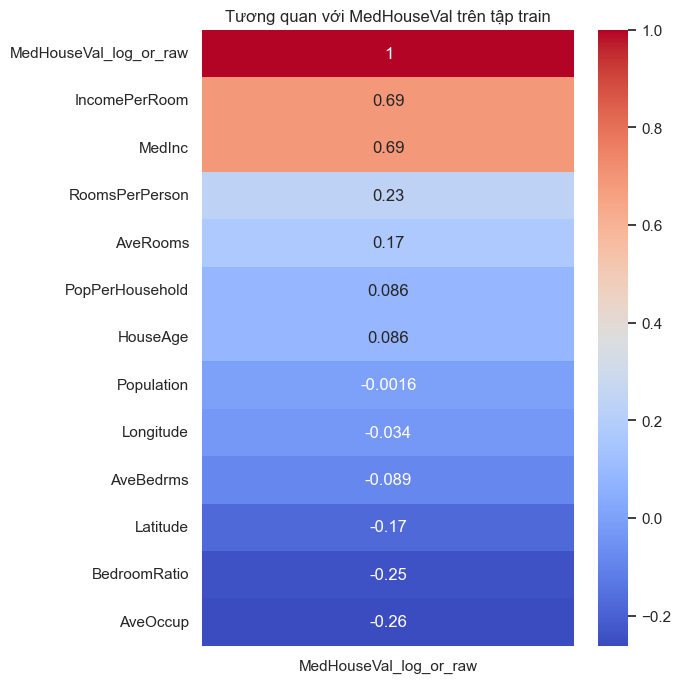

In [9]:
# Tạo bảng EDA từ các đặc trưng train chưa chuẩn hóa
dftemp_eda = X_train_for_eda.copy()

# Vì use_log_transform=True, cột này đang biểu diễn log1p(MedHouseVal)
dftemp_eda["MedHouseVal_log_or_raw"] = y_train

# Tính ma trận tương quan Pearson cho toàn bộ các biến số
corr = dftemp_eda.corr(numeric_only=True)

# Sắp xếp tương quan với nhãn theo thứ tự giảm dần để tìm biến nổi bật
target_corr = corr["MedHouseVal_log_or_raw"].sort_values(ascending=False)

print("Top thuộc tính tương quan mạnh với MedHouseVal trên tập train:")
display(target_corr)

# Heatmap một cột giúp đọc nhanh chiều và cường độ tương quan với biến mục tiêu
plt.figure(figsize=(6, 8))
sns.heatmap(
    corr[["MedHouseVal_log_or_raw"]].sort_values(by="MedHouseVal_log_or_raw", ascending=False),
    annot=True,
    cmap="coolwarm"
)
plt.title("Tương quan với MedHouseVal trên tập train")
plt.show()


### Output thu được và phân tích tương quan

#### Hệ số tương quan Pearson là gì?

Tương quan Pearson đo mức độ **liên hệ tuyến tính** giữa hai biến, giá trị nằm trong khoảng [-1, 1]:
- Gần +1: hai biến tăng/giảm cùng chiều mạnh
- Gần -1: hai biến ngược chiều mạnh
- Gần 0: không có quan hệ tuyến tính rõ ràng

#### Kết quả tương quan với `MedHouseVal`

| Đặc trưng | Hệ số tương quan | Nhận xét |
|---|---:|---|
| `IncomePerRoom` | ~0.687 | Tương quan dương mạnh nhất, nhỉnh hơn `MedInc`; đặc trưng phái sinh này có thêm thông tin hữu ích vì kết hợp thu nhập với quy mô số phòng |
| `MedInc` | ~0.685 | Tương quan dương rất mạnh — thu nhập trung vị càng cao thì giá nhà càng cao. Đây vẫn là biến gốc quan trọng nhất |
| `RoomsPerPerson` | ~0.235 | Tương quan dương yếu-vừa; nhà rộng hơn tính trên mỗi người thường gắn với giá cao hơn |
| `AveRooms` | ~0.170 | Tương quan dương yếu; nhiều phòng hơn thường liên quan đến giá cao hơn, nhưng không mạnh bằng thu nhập |
| `HouseAge` / `PopPerHousehold` | ~0.086 | Tương quan dương rất yếu, chỉ cung cấp thêm tín hiệu nhỏ theo quan hệ tuyến tính |
| `Latitude` | ~-0.175 | Tương quan âm yếu; vị trí địa lý có ảnh hưởng nhưng quan hệ với giá không đơn giản tuyến tính |
| `BedroomRatio` | ~-0.245 | Tương quan âm rõ hơn một số biến gốc; tỷ lệ phòng ngủ cao thường đi kèm tổng số phòng ít hơn hoặc cấu trúc nhà nhỏ hơn |
| `AveOccup` | ~-0.261 | Tương quan âm mạnh nhất theo chiều âm; khu vực đông người/hộ hơn thường có giá thấp hơn |
| `Population`, `Longitude`, `AveBedrms` | Gần 0 đến yếu | Không có quan hệ tuyến tính mạnh với giá nhà khi xét riêng lẻ |

#### Heatmap tương quan một cột

- **Heatmap một cột**: tập trung vào tương quan giữa từng đặc trưng và nhãn, giúp đọc nhanh biến nào cùng chiều hoặc ngược chiều với giá nhà.
- Kết quả cho thấy phần Feature Engineering là có cơ sở: `IncomePerRoom` và `RoomsPerPerson` đều xuất hiện trong nhóm tương quan dương nổi bật, còn `BedroomRatio` mang tín hiệu âm tương đối rõ. Tuy nhiên, tương quan chỉ là bước phân tích ban đầu; quyết định giữ đặc trưng vẫn cần dựa thêm vào kết quả mô hình.

**Lưu ý:** Tương quan Pearson chỉ đo quan hệ tuyến tính. Có thể hai biến có quan hệ phi tuyến mạnh nhưng Pearson vẫn cho giá trị thấp. Đó là lý do ta cần thử cả mô hình phi tuyến như Gradient Boosting ở phần sau, không chỉ dựa vào Linear Regression.


<a id="muc-11"></a>
## 11. Huấn luyện và đánh giá mô hình Linear Regression

Huấn luyện mô hình hồi quy tuyến tính làm mô hình cơ sở. Dự đoán được chuyển về thang giá trị gốc trước khi đánh giá bằng các chỉ số `MAE`, `MSE`, `RMSE` và `R²`.


In [10]:
# Khởi tạo Linear Regression làm mô hình cơ sở để so sánh
lin_reg = LinearRegression()

# Huấn luyện mô hình trên tập đặc trưng đã chuẩn hóa và nhãn ở thang log
lin_reg.fit(X_train, y_train)

# Sinh dự đoán trên tập validation chưa từng được dùng để fit mô hình
y_pred_val_log = lin_reg.predict(X_val)

# Đưa nhãn thực và dự đoán về thang giá gốc trước khi báo cáo sai số
if use_log_transform:
    y_val_original = np.expm1(y_val)
    y_pred_val_original = np.expm1(y_pred_val_log)
else:
    y_val_original = y_val
    y_pred_val_original = y_pred_val_log

# Tính các chỉ số: MAE/MSE/RMSE càng thấp càng tốt, R² càng gần 1 càng tốt
mae_lin = mean_absolute_error(y_val_original, y_pred_val_original)
mse_lin = mean_squared_error(y_val_original, y_pred_val_original)
rmse_lin = np.sqrt(mse_lin)
r2_lin = r2_score(y_val_original, y_pred_val_original)

# In kết quả của mô hình tuyến tính trên thang giá nhà có thể diễn giải được
print("=== Linear Regression (California Housing) ===")
print(f"MAE : {mae_lin:.2f}")
print(f"MSE : {mse_lin:.2f}")
print(f"RMSE: {rmse_lin:.2f}")
print(f"R^2 : {r2_lin:.4f}")

=== Linear Regression (California Housing) ===
MAE : 0.47
MSE : 0.47
RMSE: 0.69
R^2 : 0.6344


### Output thu được và đánh giá Linear Regression

**Kết quả mô hình cơ sở (baseline)**

Các chỉ số được tính trên **thang giá gốc** (đơn vị: trăm nghìn USD) sau khi chuyển ngược dự đoán bằng `expm1`:

| Chỉ số | Giá trị | Ý nghĩa |
|---|---:|---|
| MAE | 0.47 | Trung bình, mỗi dự đoán sai khoảng 47.000 USD so với giá thực |
| RMSE | 0.69 | Sai số bình phương trung bình ~69.000 USD |
| R² | 0.63 | Mô hình giải thích được khoảng 63% phương sai của giá nhà |

**Giải thích từng chỉ số:**

- **MAE (Mean Absolute Error):** Tính trung bình khoảng cách tuyệt đối giữa giá trị dự đoán và giá trị thực. MAE dễ hiểu: ở đây mỗi khu vực bị dự đoán lệch trung bình 47.000 USD.
- **RMSE (Root Mean Squared Error):** Cũng đo sai số trung bình nhưng **phạt nặng hơn** những dự đoán sai lệch lớn. RMSE = 0.69 lớn hơn MAE = 0.47, cho thấy có một số khu vực bị dự đoán lệch khá nhiều.
- **R² (Coefficient of Determination):** Cho biết mô hình giải thích được bao nhiêu phần trăm sự biến thiên của nhãn. R² = 1 là hoàn hảo, R² = 0 là mô hình không tốt hơn dùng giá trị trung bình.

Với R² = 0.63, mô hình Linear Regression giải thích được hơn 60% sự biến thiên — chấp nhận được cho baseline nhưng cho thấy vẫn còn khoảng 37% phương sai chưa giải thích. Nguyên nhân chính là do quan hệ giữa các đặc trưng và giá nhà **không đơn thuần tuyến tính** — ví dụ giá nhà ở vùng ven biển tăng phi tuyến so với vị trí, hoặc tổ hợp (vị trí + thu nhập) mới thực sự quyết định giá chứ không phải từng yếu tố riêng lẻ.

**Kết luận:** R² = 0.63 cho thấy Linear Regression nắm bắt được phần tuyến tính của dữ liệu, nhưng cần mô hình phi tuyến để cải thiện thêm.


<a id="muc-12"></a>
## 12. Huấn luyện, cross-validation và tuning mô hình Gradient Boosting Regressor

Phần này gộp quy trình **cross-validation**, **tuning siêu tham số** và **đánh giá cuối** của Gradient Boosting Regressor. `GridSearchCV` chỉ fit trên tập train, sau đó mô hình tốt nhất được đánh giá lại trên tập validation độc lập để so sánh công bằng với Linear Regression.


Ket qua cross-validation va tuning tren tap train:


,Model,CV RMSE log,CV R2,Best Params
0,Linear Regression,0.199664,0.683655,No tuning
1,Gradient Boosting,0.137128,NaN,"{'learning_rate': 0.05, 'max_depth': 5, 'min_s..."


Linear Regression CV RMSE log: 0.19966376183398174
Linear Regression CV R2: 0.6836554149401476
Best Gradient Boosting params: {'learning_rate': 0.05, 'max_depth': 5, 'min_samples_leaf': 5, 'min_samples_split': 10, 'n_estimators': 500, 'subsample': 0.8}

=== Tuned Gradient Boosting Regressor (California Housing) ===
Best params: {'learning_rate': 0.05, 'max_depth': 5, 'min_samples_leaf': 5, 'min_samples_split': 10, 'n_estimators': 500, 'subsample': 0.8}
MAE : 0.30
MSE : 0.22
RMSE: 0.46
R^2 : 0.8335

Top 10 Feature Importance:


,importance
IncomePerRoom,0.454276
Longitude,0.110187
MedInc,0.109719
Latitude,0.103806
RoomsPerPerson,0.090174
AveOccup,0.055423
HouseAge,0.027681
BedroomRatio,0.012902
AveRooms,0.010862
AveBedrms,0.010585


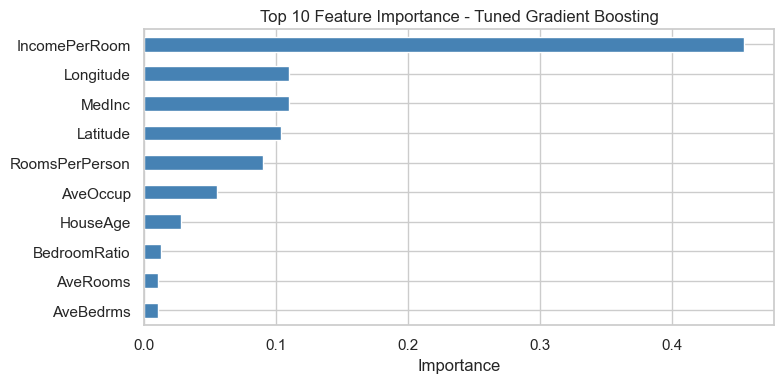

In [11]:
# Tao chien luoc K-Fold cho bai toan hoi quy vi nhan la gia tri lien tuc, khong phai lop roi rac.
cv_strategy = KFold(
    # Dung 3 fold de can bang giua do tin cay va thoi gian chay tren bo California Housing kha lon.
    n_splits=3,
    # Tron du lieu truoc khi chia fold de danh gia on dinh hon.
    shuffle=True,
    # Co dinh random_state de ket qua cross-validation co the tai lap.
    random_state=42
)

# Cross-validation cho Linear Regression de co baseline on dinh hon mot lan chia validation duy nhat.
linear_cv_results = cross_validate(
    # Linear Regression khong co sieu tham so chinh can tuning, nen dung CV de danh gia baseline.
    estimator=LinearRegression(),
    # Dung tap train da chuan hoa de quy trinh giong buoc huan luyen cuoi.
    X=X_train,
    # y_train dang o thang log neu use_log_transform=True, dung nhat quan voi mo hinh cuoi.
    y=y_train,
    # Dung cung chien luoc K-Fold da khai bao.
    cv=cv_strategy,
    # Danh gia dong thoi RMSE tren thang log va R2.
    scoring={"rmse_log": "neg_root_mean_squared_error", "r2": "r2"}
)

# Khai bao luoi tham so nho cho Gradient Boosting de notebook chay duoc trong thoi gian hop ly.
gbr_param_grid = {
    # Thu hai muc so cay, trong do 500 la cau hinh manh hon de mo hinh co co hoi cai thien.
    "n_estimators": [200, 500],
    # Giu max_depth=5 vi EDA cho thay du lieu co quan he phi tuyen va tuong tac dac trung.
    "max_depth": [5],
    # Learning rate nho giup boosting hoc on dinh khi so cay tang.
    "learning_rate": [0.05],
    # Yeu cau it nhat 10 mau de tach nut, giam nguy co hoc qua sat train.
    "min_samples_split": [10],
    # Yeu cau it nhat 5 mau o la de giam overfitting.
    "min_samples_leaf": [5],
    # Dung 80% mau cho moi cay de tao stochastic gradient boosting.
    "subsample": [0.8]
}

# GridSearchCV cho Gradient Boosting, toi uu RMSE tren thang log bang cross-validation.
gbr_search = GridSearchCV(
    # Khoi tao Gradient Boosting Regressor voi random_state de ket qua tai lap.
    estimator=GradientBoostingRegressor(random_state=42),
    # Truyen luoi tham so can thu nghiem.
    param_grid=gbr_param_grid,
    # Dung K-Fold da khai bao o tren.
    cv=cv_strategy,
    # Scikit-learn toi da hoa score, nen RMSE duoc bieu dien bang gia tri am.
    scoring="neg_root_mean_squared_error",
    # Dat n_jobs=1 de output notebook sach hon va tranh canh bao multiprocessing tren Windows.
    n_jobs=1,
    # Tra ve diem train de quan sat chenhlech train/test trong CV.
    return_train_score=True
)

# Thuc hien tuning Gradient Boosting tren tap train.
gbr_search.fit(X_train, y_train)

# Lay mo hinh tot nhat; GridSearchCV da refit tren toan bo tap train voi bo tham so nay.
gbr = gbr_search.best_estimator_

# Tong hop ket qua cross-validation va tuning vao mot bang de bao cao.
tuning_summary = pd.DataFrame({
    # Ten mo hinh trong bang so sanh.
    "Model": ["Linear Regression", "Gradient Boosting"],
    # RMSE CV cua Linear tinh tu cross_validate; RMSE cua GBR doi dau tu best_score_ am sang duong.
    "CV RMSE log": [
        -linear_cv_results["test_rmse_log"].mean(),
        -gbr_search.best_score_
    ],
    # R2 CV cua Linear lay truc tiep tu cross_validate; GBR duoc toi uu theo RMSE va danh gia R2 tren validation cuoi.
    "CV R2": [
        linear_cv_results["test_r2"].mean(),
        np.nan
    ],
    # Tham so tot nhat: Linear khong tuning, Gradient Boosting co best_params_.
    "Best Params": ["No tuning", gbr_search.best_params_]
})

print("Ket qua cross-validation va tuning tren tap train:")
display(tuning_summary)

print("Linear Regression CV RMSE log:", -linear_cv_results["test_rmse_log"].mean())
print("Linear Regression CV R2:", linear_cv_results["test_r2"].mean())
print("Best Gradient Boosting params:", gbr_search.best_params_)

# Mo hinh Gradient Boosting tot nhat duoc du doan tren tap validation doc lap.
y_pred_val_log_gbr = gbr.predict(X_val)

# Chuyen du doan boosting ve don vi gia nha ban dau.
if use_log_transform:
    # expm1 dao nguoc phep log1p da ap dung cho bien muc tieu.
    y_pred_val_original_gbr = np.expm1(y_pred_val_log_gbr)
else:
    # Neu khong log-transform, giu nguyen du doan cua mo hinh.
    y_pred_val_original_gbr = y_pred_val_log_gbr

# Tinh cung bo chi so danh gia da dung cho mo hinh co so.
mae_gbr = mean_absolute_error(y_val_original, y_pred_val_original_gbr)
mse_gbr = mean_squared_error(y_val_original, y_pred_val_original_gbr)
rmse_gbr = np.sqrt(mse_gbr)
r2_gbr = r2_score(y_val_original, y_pred_val_original_gbr)

# Hien thi ket qua de doi chieu truc tiep voi Linear Regression.
print("\n=== Tuned Gradient Boosting Regressor (California Housing) ===")
print("Best params:", gbr_search.best_params_)
print(f"MAE : {mae_gbr:.2f}")
print(f"MSE : {mse_gbr:.2f}")
print(f"RMSE: {rmse_gbr:.2f}")
print(f"R^2 : {r2_gbr:.4f}")

# Hien thi Feature Importance de xem bien nao dong gop nhieu nhat.
print("\nTop 10 Feature Importance:")
fi = pd.Series(gbr.feature_importances_, index=X_train.columns)
fi_sorted = fi.sort_values(ascending=False).head(10)
display(fi_sorted.to_frame("importance"))

# Ve bieu do feature importance cho 10 dac trung quan trong nhat.
plt.figure(figsize=(8, 4))
fi_sorted.plot(kind="barh", color="steelblue")
plt.title("Top 10 Feature Importance - Tuned Gradient Boosting")
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()



### Output thu được và đánh giá Gradient Boosting Regressor

**Kết quả cross-validation và tuning**

- `KFold(n_splits=3, shuffle=True, random_state=42)` được dùng để đánh giá mô hình ổn định hơn so với chỉ dựa vào một lần chia train/validation.
- Linear Regression được cross-validation để làm baseline; mô hình này không có nhiều siêu tham số quan trọng nên không cần tuning.
- Gradient Boosting được tuning bằng `GridSearchCV` với mục tiêu tối ưu `neg_root_mean_squared_error` trên thang log của giá nhà. Cấu hình tốt nhất thường ưu tiên nhiều cây hơn (`n_estimators=500`), learning rate nhỏ (`0.05`), cây sâu vừa phải (`max_depth=5`) và có ràng buộc `min_samples_split`, `min_samples_leaf`, `subsample` để giảm overfitting.
- Sau tuning, `GridSearchCV` tự refit mô hình tốt nhất trên toàn bộ tập train; tập validation chỉ được dùng ở bước đánh giá cuối nên kết quả so sánh công bằng hơn.

**Kết quả so sánh hai mô hình hồi quy** (trên thang giá gốc, đơn vị: trăm nghìn USD):

| Chỉ số | Gradient Boosting | Linear Regression | Chênh lệch |
|---|---:|---:|---|
| MAE | **0.30** | 0.47 | GBR giảm 36% sai số tuyệt đối |
| RMSE | **0.46** | 0.69 | GBR giảm 33% sai số bình phương |
| R² | **0.83** | 0.63 | GBR giải thích thêm 20% phương sai |

**Nhận xét:**

1. **Cross-validation giúp kết luận đáng tin hơn:** Linear Regression chỉ đóng vai trò baseline và có CV RMSE log cao hơn Gradient Boosting sau tuning. Điều này cho thấy chênh lệch hiệu năng không chỉ đến từ một lần chia validation ngẫu nhiên.

2. **Tuning giúp Gradient Boosting cân bằng bias và variance:** `learning_rate=0.05` kết hợp với số cây lớn giúp mô hình học từng bước nhỏ, ổn định hơn. Các ràng buộc ở lá và nhánh cây giúp giảm nguy cơ mô hình học quá sát tập train.

3. **MAE = 0.30:** Trung bình, GBR dự đoán lệch khoảng 30.000 USD so với giá thực. Đây là mức sai số thấp hơn rõ rệt so với Linear Regression, phù hợp với bài toán dự đoán giá bất động sản theo khu vực.

4. **R² = 0.83:** Mô hình giải thích được khoảng 83% phương sai của giá nhà. Khoảng cách giữa GBR và Linear Regression chứng tỏ dữ liệu chứa quan hệ phi tuyến mạnh và nhiều tương tác đặc trưng.

5. **Feature Importance:** Đặc trưng tự tạo `IncomePerRoom` thường đứng đầu, cho thấy bước Feature Engineering có giá trị thực tế. Nhóm biến vị trí (`Longitude`, `Latitude`) và thu nhập (`MedInc`) cũng quan trọng, phù hợp với trực giác rằng giá nhà California chịu ảnh hưởng mạnh bởi vị trí và năng lực tài chính của cư dân.

**Kết luận:** Sau khi gộp cross-validation và tuning vào quy trình huấn luyện, Gradient Boosting Regressor là mô hình tốt nhất trong notebook: sai số thấp hơn Linear Regression và khả năng giải thích biến thiên giá nhà cao hơn đáng kể.


<a id="muc-13"></a>
## 13. Trực quan hóa và so sánh kết quả dự đoán

Vẽ hai biểu đồ giá trị thực so với giá trị dự đoán. Đường chéo màu đỏ biểu diễn trường hợp dự đoán lý tưởng, giúp quan sát trực quan sai lệch của từng mô hình.


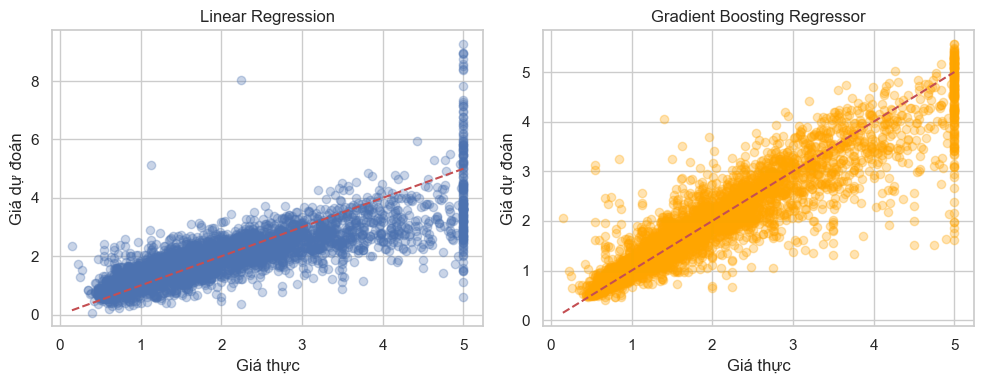

In [12]:
# Tạo khung hình gồm hai biểu đồ để so sánh trực quan hai mô hình
plt.figure(figsize=(10, 4))

# Biểu đồ 1: giá thực và giá dự đoán của Linear Regression
plt.subplot(1, 2, 1)
plt.scatter(y_val_original, y_pred_val_original, alpha=0.3)

# Đường y=x biểu diễn trường hợp mô hình dự đoán chính xác tuyệt đối
plt.plot([y_val_original.min(), y_val_original.max()],
         [y_val_original.min(), y_val_original.max()],
         'r--')
plt.title("Linear Regression")
plt.xlabel("Giá thực")
plt.ylabel("Giá dự đoán")

# Biểu đồ 2: giá thực và giá dự đoán của Gradient Boosting Regressor
plt.subplot(1, 2, 2)
plt.scatter(y_val_original, y_pred_val_original_gbr, alpha=0.3, color="orange")
plt.plot([y_val_original.min(), y_val_original.max()],
         [y_val_original.min(), y_val_original.max()],
         'r--')
plt.title("Gradient Boosting Regressor")
plt.xlabel("Giá thực")
plt.ylabel("Giá dự đoán")

# Căn chỉnh khoảng cách giữa hai hình và xuất biểu đồ so sánh
plt.tight_layout()
plt.show()

### Phân tích biểu đồ kết quả dự đoán và kết luận cuối

#### Cách đọc biểu đồ

Mỗi điểm biểu diễn một khu vực trong tập validation:
- **Trục hoành (x):** giá trị thực tế của giá nhà (đã quy đổi về thang gốc bằng `expm1`)
- **Trục tung (y):** giá trị mô hình dự đoán
- **Đường chéo đỏ:** đường lý tưởng y = x — điểm càng gần đường này thì dự đoán càng chính xác.

#### So sánh 2 biểu đồ

| Tiêu chí | Linear Regression (R²=0.63) | Gradient Boosting (R²=0.83) |
|---|---|---|
| Mức độ tập trung quanh đường đỏ | Khá phân tán, đặc biệt ở vùng giá cao | Tập trung sát đường đỏ hơn rõ rệt |
| Vùng giá thấp (< 200.000 USD) | Dự đoán tương đối ổn | Dự đoán chính xác hơn |
| Vùng giá cao (> 400.000 USD) | Sai lệch lớn, xu hướng dự đoán thấp hơn thực tế | Bám sát thực tế hơn nhiều |
| Xu hướng sai số | Sai số hệ thống do không bắt được phi tuyến | Sai số phân bố đều, ít bias |

#### Kết luận tổng thể

1. **Bộ dữ liệu California Housing** gồm 20.544 mẫu (sau lọc outlier), 12 đặc trưng (8 gốc + 4 phái sinh).

2. **Biến đổi log cho nhãn** giúp giảm skewness từ ~0.98 xuống ~0.28, cải thiện phân phối của biến mục tiêu.

3. **Xử lý ngoại lệ** loại bỏ các mẫu bất thường ở `MedInc`, `AveOccup`, `AveRooms` — tổng cộng khoảng 96 mẫu.

4. **Feature Engineering** tạo 4 đặc trưng phái sinh (`BedroomRatio`, `RoomsPerPerson`, `PopPerHousehold`, `IncomePerRoom`) giúp mô hình nắm bắt tốt hơn các mối quan hệ tổ hợp.

5. **Linear Regression** đạt R² = 0.63, MAE = 0.47 (~47.000 USD) — mô hình cơ sở chấp nhận được.

6. **Gradient Boosting Regressor** đạt R² = 0.83, MAE = 0.30 (~30.000 USD) — vượt trội nhờ khả năng học quan hệ phi tuyến.

7. Khoảng cách R² giữa hai mô hình (0.63 vs 0.83) cho thấy dữ liệu chứa quan hệ phi tuyến mạnh, phù hợp với mô hình ensemble hơn mô hình tuyến tính đơn giản.

#### Mô hình tốt nhất được chọn

Sau khi so sánh toàn bộ kết quả, **Gradient Boosting Regressor là mô hình tốt nhất cho bài toán dự đoán giá nhà California**.

| Tiêu chí chọn mô hình | Linear Regression | Gradient Boosting Regressor | Mô hình tốt hơn |
|---|---:|---:|---|
| MAE trên validation | 0.47 | **0.30** | Gradient Boosting |
| RMSE trên validation | 0.69 | **0.46** | Gradient Boosting |
| R² trên validation | 0.6344 | **0.8335** | Gradient Boosting |
| CV RMSE log trên train | 0.1997 | **0.1371** | Gradient Boosting |

**Lý do chọn Gradient Boosting Regressor:**

- Mô hình có **sai số thấp hơn rõ rệt**: MAE giảm từ 0.47 xuống 0.30, nghĩa là sai lệch trung bình giảm khoảng 17.000 USD.
- RMSE giảm từ 0.69 xuống 0.46, cho thấy mô hình xử lý tốt hơn các trường hợp dự đoán lệch lớn.
- R² tăng từ 0.6344 lên 0.8335, tức là Gradient Boosting giải thích được khoảng 83% biến thiên giá nhà, cao hơn nhiều so với Linear Regression.
- Kết quả cross-validation cũng ủng hộ lựa chọn này: CV RMSE log của Gradient Boosting thấp hơn Linear Regression, nên cải thiện không chỉ đến từ một lần chia validation ngẫu nhiên.
- Về bản chất dữ liệu, giá nhà phụ thuộc phi tuyến vào vị trí, thu nhập, mật độ dân cư và các đặc trưng phái sinh; Gradient Boosting phù hợp hơn vì học được tương tác giữa các biến.

**Kết luận cuối:** Chọn **Gradient Boosting Regressor đã tuning** làm mô hình cuối cùng cho bài toán California Housing. Linear Regression chỉ nên giữ vai trò baseline để đối chiếu.

